# Which probe should feed the safeguard?

Binary search measures the phase several times during exploration, at **increasing depths**. The
statistical safeguard

$$N^{*}=\arg\max_{1\le N\le N_{\max}}\;
\underbrace{\mathbb P\!\left(\phi<\tfrac{\pi}{2N}\,\middle|\,\hat\phi_0\right)}_{\text{no overshoot}}
\cdot\underbrace{\left[2\Phi\!\left(2\varepsilon\sqrt{NB}\right)-1\right]}_{\text{converges}}$$

needs exactly **one** pilot $(\hat\phi_0,\sigma)$. Which one?

| choice | $\sigma=\dfrac{1}{2N_0\sqrt{m'}}$ | aliasing risk |
|---|---|---|
| `first` — the opening probe at $N_{\min}$ | largest | **none**: $N_{\min}\phi\le\pi/2$ holds by construction for every admissible $\phi$ |
| `deep` — deepest probe not flagged as an overshoot | smaller by $N_{\min}/N_{\rm acc}$ | rests on the overshoot *test*, which can miss |
| `last` — the final probe, flagged or not | smaller | highest |
| `pool` — inverse-variance combination of all unflagged probes | smallest | inherits `deep`'s, spread over more probes |

**`deep` is what the repository currently implements.** The trade-off is precision against latent
aliasing, and the direction is not obvious: a missed overshoot biases $\hat\phi_0$ **low**, which makes
the rule believe $\phi$ is smaller than it is and choose an even **deeper** $N$ — the error compounds
rather than cancels.

This notebook is self-contained: everything is re-implemented below, nothing is imported from the
repository, so you can edit any part and re-run.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ndtr
from scipy.stats import norm

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
                     "font.size": 9})
VARIANTS = ["first", "deep", "last", "pool"]
COL = {"first": "#2ca02c", "deep": "#d62728", "last": "#7f7f7f", "pool": "#1f77b4"}
print("ready")


ready


## 1. The model, the estimator, and the safeguard


In [2]:
def simulate(rng, phi, m, N):
    """One estimate from m shots at depth N.  hits ~ Binomial(m, cos^2(N phi)),
    phi_hat = arccos(sqrt(hits/m))/N.   Var(phi_hat) = 1/(4 N^2 m), independent of phi."""
    if m < 1 or N < 1:
        return np.nan
    p0 = np.cos(N * phi) ** 2
    hits = rng.binomial(m, p0)
    return float(np.arccos(np.sqrt(hits / m)) / N)


def pilot_sd(N, m):
    return 1.0 / (2.0 * N * np.sqrt(m))


def p_safe(N, phi_hat, sigma, support):
    """P(phi < pi/2N | pilot) under the TRUNCATED normal posterior on [phi_min, phi_max]."""
    t = np.pi / (2.0 * np.asarray(N, float))
    lo, hi = support
    Fa, Fb = ndtr((lo - phi_hat) / sigma), ndtr((hi - phi_hat) / sigma)
    den = Fb - Fa
    if not np.isfinite(den) or den < 1e-12:
        return (t > min(max(phi_hat, lo), hi)).astype(float)
    return np.clip((ndtr((t - phi_hat) / sigma) - Fa) / den, 0.0, 1.0)


def score(N, phi_hat, sigma, budget, eps, support):
    Nf = np.asarray(N, float)
    p_conv = 2.0 * ndtr(2.0 * eps * np.sqrt(Nf * float(budget))) - 1.0
    return p_safe(Nf, phi_hat, sigma, support) * p_conv


def risk_optimal_depth(phi_hat, sigma, budget, eps, N_max, support):
    """Exact integer argmax over 1..N_max (N_max is small enough here to scan exhaustively)."""
    if not np.isfinite(phi_hat) or sigma <= 0 or budget <= 0:
        return 1
    cand = np.arange(1, int(N_max) + 1, dtype=np.int64)
    return int(cand[int(np.argmax(score(cand, phi_hat, sigma, budget, eps, support)))])


## 2. The bisection, recording every probe

Identical arithmetic to Algorithm 5. Each probe is tagged `accepted` when it is **not** flagged as an
overshoot by the criterion $\hat\phi < \Phi^{-1}(1-\alpha;\,\hat\phi_{\rm prev},\sigma_{\rm prev})$.


In [3]:
def explore(rng, phi, phi_max, phi_min, m_exp, budget, conf):
    """Returns (probes, budget_used); probes = [(N, phi_hat, accepted), ...]."""
    N_min = max(np.pi // (2 * phi_max), 1)
    N_max = max(np.pi // (2 * phi_min), 1)
    N = max(1, N_min)
    if m_exp * N > budget:
        return None
    phi_hat = simulate(rng, phi, m_exp, N)
    used = m_exp * N
    phi_1 = norm.ppf(1 - conf, phi_hat, np.sqrt(1 / (4 * m_exp * N**2)))
    probes = [(N, phi_hat, True)]
    lb, ub = N_min, N_max
    N += (ub - N) // 2
    done = False
    while not done:
        phi_hat = simulate(rng, phi, m_exp, N)
        used += m_exp * N
        temp_N = N
        if phi_hat < phi_1:
            probes.append((temp_N, phi_hat, False))
            N -= (N - lb) // 2
            ub = temp_N
        else:
            probes.append((temp_N, phi_hat, True))
            N += (ub - N) // 2
            lb = temp_N
            phi_1 = norm.ppf(1 - conf, phi_hat, np.sqrt(1 / (4 * m_exp * N**2)))
        if temp_N == N or N < N_min or N > N_max or used >= budget:
            done = True
    return probes, used


def pilot_from(probes, m_exp, which):
    ok = [(N, p) for N, p, a in probes if a and np.isfinite(p)]
    if which == "last":
        fin = [(N, p) for N, p, _ in probes if np.isfinite(p)]
        if not fin:
            return None
        N, p = fin[-1]
        return p, pilot_sd(N, m_exp)
    if not ok:
        return None
    if which == "first":
        N, p = ok[0];  return p, pilot_sd(N, m_exp)
    if which == "deep":
        N, p = ok[-1]; return p, pilot_sd(N, m_exp)
    if which == "pool":
        Nk = np.array([N for N, _ in ok], float); ph = np.array([p for _, p in ok], float)
        w = Nk ** 2
        return float((w * ph).sum() / w.sum()), 1.0 / (2.0 * np.sqrt(m_exp * w.sum()))
    raise ValueError(which)


## 3. One run, in detail

The panel below shows a single trial: every probe the bisection took, which ones it accepted, the
four candidate pilots, and the depth each one leads to. $N_{\rm opt}=\lfloor\pi/2\phi\rfloor$ is the
aliasing limit — **any $N$ to the right of it overshoots and the trial cannot converge.**


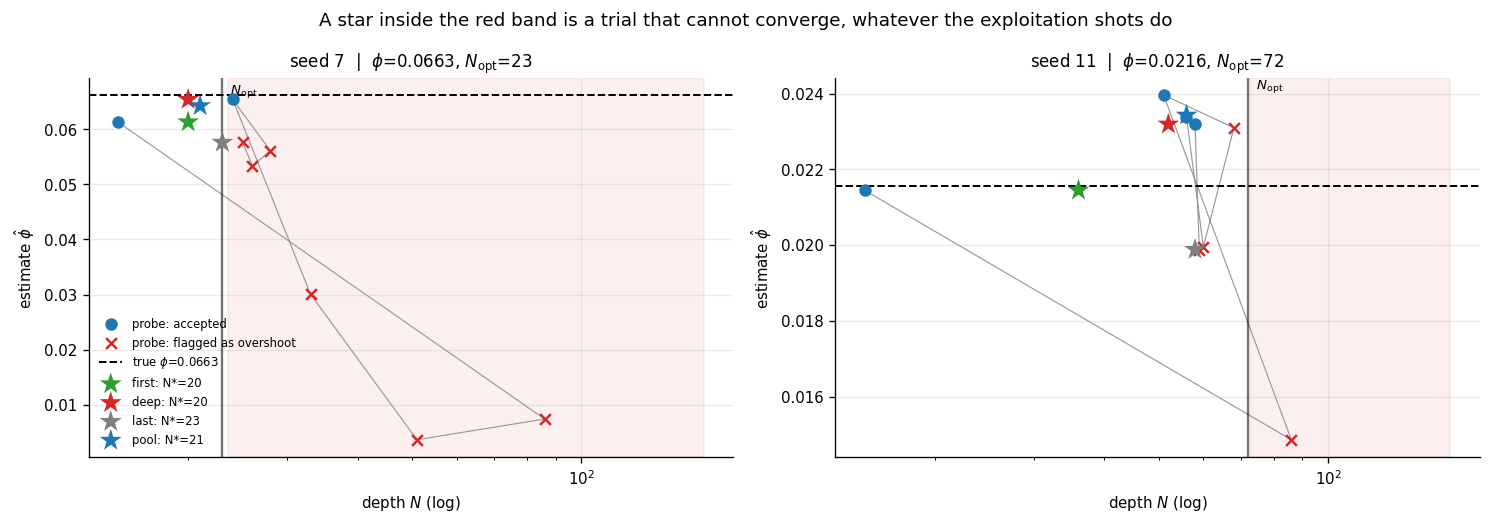

In [4]:
SET = dict(phi_min=0.01, phi_max=0.1, eps=1e-3)
BUDGET, M_EXP, CONF = 200_000, 60, 0.8


def one_run(seed, budget=BUDGET, m_exp=M_EXP, conf=CONF, **s):
    s = {**SET, **s}
    rng = np.random.default_rng(seed)
    phi = float(rng.uniform(s["phi_min"], s["phi_max"]))
    out = explore(rng, phi, s["phi_max"], s["phi_min"], m_exp, budget, conf)
    if out is None:
        return None
    probes, used = out
    rem = budget - used
    if rem <= 0:
        return None
    N_max = max(int(np.pi // (2 * s["phi_min"])), 1)
    picks = {}
    for v in VARIANTS:
        pil = pilot_from(probes, m_exp, v)
        if pil is None or not np.isfinite(pil[0]):
            continue
        N = risk_optimal_depth(pil[0], pil[1], rem, s["eps"], N_max, (s["phi_min"], s["phi_max"]))
        picks[v] = dict(phi_pilot=pil[0], sigma=pil[1], N=N)
    return dict(phi=phi, probes=probes, used=used, rem=rem, picks=picks,
                N_opt=max(1, int(np.pi // (2 * phi))), N_max=N_max, **s)


def plot_run(r, ax=None):
    ax = ax or plt.gca()
    P = np.array([(N, p) for N, p, _ in r["probes"]])
    acc = np.array([a for _, _, a in r["probes"]])
    ax.scatter(P[acc, 0], P[acc, 1], s=42, color="#1f77b4", zorder=4, label="probe: accepted")
    ax.scatter(P[~acc, 0], P[~acc, 1], s=42, marker="x", color="#d62728", zorder=4,
               label="probe: flagged as overshoot")
    ax.plot(P[:, 0], P[:, 1], lw=0.7, color="0.6", zorder=2)
    ax.axhline(r["phi"], color="k", ls="--", lw=1.2, label=rf"true $\phi$={r['phi']:.4f}")
    ax.axvline(r["N_opt"], color="k", lw=1.4, alpha=0.55)
    ax.text(r["N_opt"], ax.get_ylim()[1], r"  $N_{\rm opt}$", va="top", fontsize=8)
    ax.axvspan(r["N_opt"] + 0.5, r["N_max"] * 1.05, color="#d62728", alpha=0.07, zorder=0)
    for v, d in r["picks"].items():
        bad = d["N"] > r["N_opt"]
        ax.scatter([d["N"]], [d["phi_pilot"]], marker="*", s=190, color=COL[v], zorder=6,
                   edgecolor="k" if bad else "none", linewidth=1.1,
                   label=f"{v}: N*={d['N']}" + ("  OVERSHOOT" if bad else ""))
    ax.set(xscale="log", xlabel="depth $N$ (log)", ylabel=r"estimate $\hat\phi$")
    return ax


def sample_runs(n=400, seed0=0, **kw):
    out = []
    for s in range(seed0, seed0 + n * 3):
        r = one_run(s, **kw)
        if r is not None and len(r["picks"]) == len(VARIANTS):
            out.append(r)
        if len(out) >= n:
            break
    return out


fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
for ax, sd in zip(axes, [7, 11]):
    r = one_run(sd)
    plot_run(r, ax)
    ax.set_title(f"seed {sd}  |  $\\phi$={r['phi']:.4f}, $N_{{\\rm opt}}$={r['N_opt']}", fontsize=10)
axes[0].legend(fontsize=7, loc="lower left")
fig.suptitle("A star inside the red band is a trial that cannot converge, whatever the exploitation shots do",
             fontsize=11)
fig.tight_layout(); plt.show()


## 3b. The trajectory: what the bisection does step by step

The panel above plots $\hat\phi$ against *depth*. This one plots both against the **bisection step**,
which is how the search actually unfolds: the top row is the probed depth $N_i$ against the true
aliasing limit $N_{\rm opt}$, the bottom row the estimate $\hat\phi_i$ against the true $\phi$.

Two things to look for:

* **the estimate collapses once $N_i>N_{\rm opt}$** — past the aliasing limit $\arccos$ folds back and
  $\hat\phi$ drops toward zero, which is exactly the signal the overshoot test is built on;
* **$L$ (the bisection's lower bound = the deepest accepted depth) creeps up toward $N_{\rm opt}$ and
  sometimes past it** — an accepted probe above $N_{\rm opt}$ is a type-I error of the test, and it
  moves $L$ into the aliased region permanently.


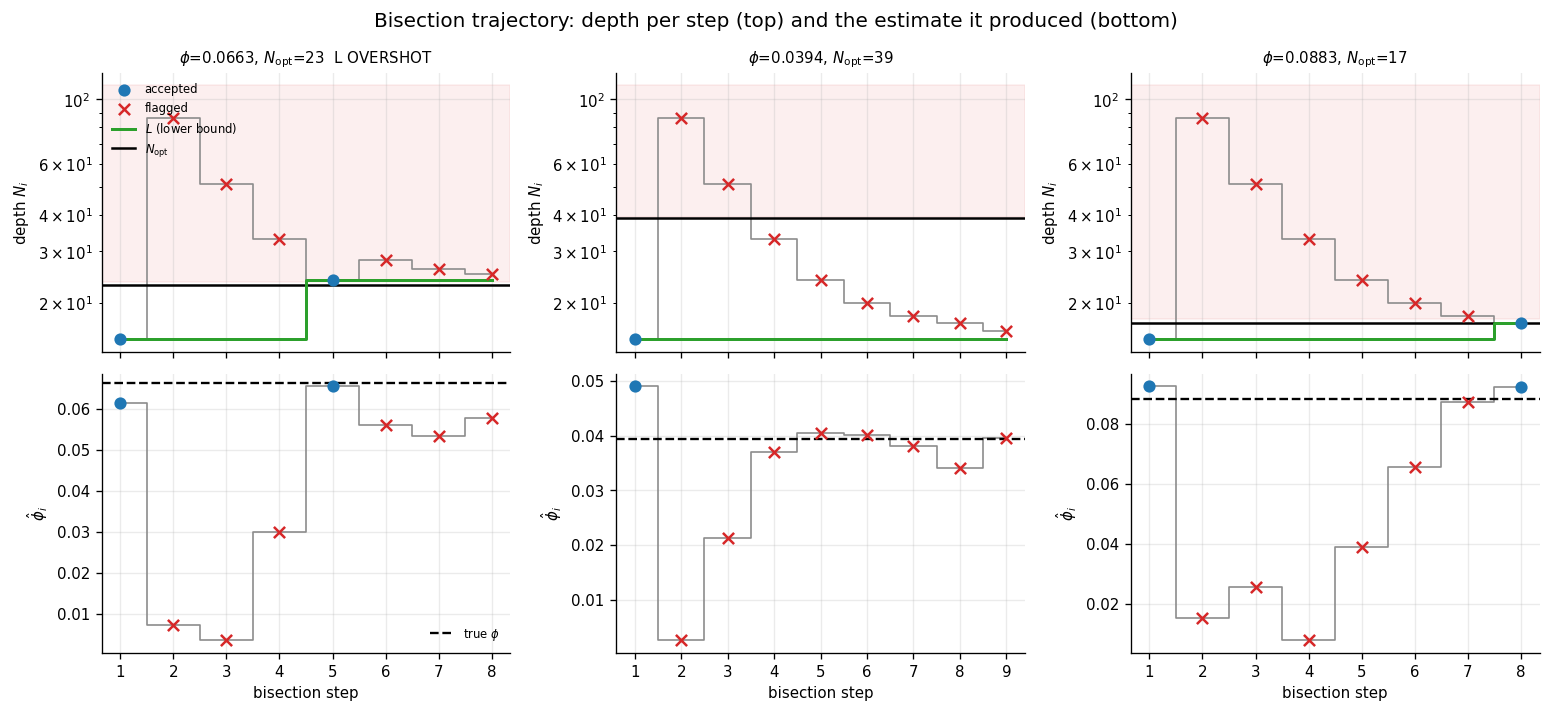

In [5]:
def plot_trajectory(r, axes):
    axN, axP = axes
    steps = np.arange(1, len(r["probes"]) + 1)
    N = np.array([p[0] for p in r["probes"]], float)
    ph = np.array([p[1] for p in r["probes"]], float)
    acc = np.array([p[2] for p in r["probes"]], bool)

    L = np.maximum.accumulate(np.where(acc, N, -np.inf))   # running lower bound
    L[~np.isfinite(L)] = np.nan

    axN.step(steps, N, where="mid", color="0.55", lw=1.0, zorder=2)
    axN.scatter(steps[acc], N[acc], s=40, color="#1f77b4", zorder=4, label="accepted")
    axN.scatter(steps[~acc], N[~acc], s=45, marker="x", color="#d62728", zorder=4, label="flagged")
    axN.step(steps, L, where="mid", color="#2ca02c", lw=1.8, zorder=3, label="$L$ (lower bound)")
    axN.axhline(r["N_opt"], color="k", lw=1.5, label=r"$N_{\rm opt}$")
    axN.axhspan(r["N_opt"] + 0.5, max(N.max(), r["N_opt"]) * 1.3, color="#d62728", alpha=0.07)
    axN.set(ylabel="depth $N_i$", yscale="log")

    axP.step(steps, ph, where="mid", color="0.55", lw=1.0, zorder=2)
    axP.scatter(steps[acc], ph[acc], s=40, color="#1f77b4", zorder=4)
    axP.scatter(steps[~acc], ph[~acc], s=45, marker="x", color="#d62728", zorder=4)
    axP.axhline(r["phi"], color="k", ls="--", lw=1.4, label=r"true $\phi$")
    axP.set(xlabel="bisection step", ylabel=r"$\hat\phi_i$")
    return axN, axP


runs3 = sample_runs(3, seed0=7)
fig, axes = plt.subplots(2, 3, figsize=(13.0, 6.0), sharex="col")
for k, r in enumerate(runs3):
    plot_trajectory(r, (axes[0, k], axes[1, k]))
    over = "  L OVERSHOT" if max(n for n, _p, a in r["probes"] if a) > r["N_opt"] else ""
    axes[0, k].set_title(f"$\\phi$={r['phi']:.4f}, $N_{{\\rm opt}}$={r['N_opt']}{over}", fontsize=9)
axes[0, 0].legend(fontsize=7, loc="upper left")
axes[1, 0].legend(fontsize=7)
fig.suptitle("Bisection trajectory: depth per step (top) and the estimate it produced (bottom)",
             fontsize=12)
fig.tight_layout(); plt.show()


### How often does $L$ land above $N_{\rm opt}$?

If $L$ were always safe it would be an attractive exploitation depth by itself — no safeguard needed.
It is not: the overshoot test is a hypothesis test with a type-I error, so probes above $N_{\rm opt}$
are sometimes accepted, and once one is, $L$ stays in the aliased region.


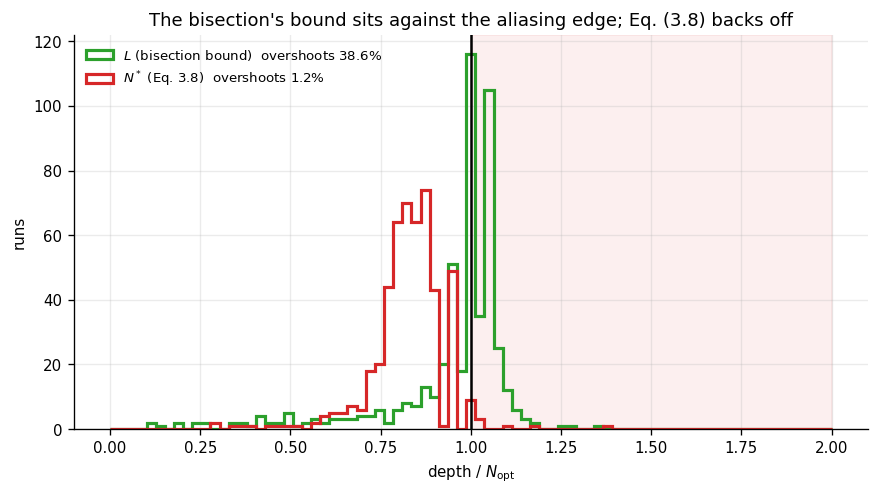

median L/N_opt  = 1.000
median N*/N_opt = 0.833
P(L  > N_opt)   = 38.60%   <- these trials cannot converge
P(N* > N_opt)   = 1.20%
P(N* > L)       = 10.40%


In [6]:
runs = sample_runs(500)
L_ratio = np.array([max(n for n, _p, a in r["probes"] if a) / r["N_opt"] for r in runs])
N_ratio = np.array([r["picks"]["deep"]["N"] / r["N_opt"] for r in runs])

fig, ax = plt.subplots(figsize=(7.4, 4.2))
bins = np.linspace(0, 2.0, 80)
ax.hist(np.clip(L_ratio, 0, 2), bins=bins, histtype="step", lw=1.9, color="#2ca02c",
        label=f"$L$ (bisection bound)  overshoots {100*(L_ratio>1).mean():.1f}%")
ax.hist(np.clip(N_ratio, 0, 2), bins=bins, histtype="step", lw=1.9, color="#d62728",
        label=f"$N^*$ (Eq. 3.8)  overshoots {100*(N_ratio>1).mean():.1f}%")
ax.axvline(1.0, color="k", lw=1.5)
ax.axvspan(1.0, 2.0, color="#d62728", alpha=0.07)
ax.set(xlabel=r"depth / $N_{\rm opt}$", ylabel="runs",
       title="The bisection's bound sits against the aliasing edge; Eq. (3.8) backs off")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

print(f"median L/N_opt  = {np.median(L_ratio):.3f}")
print(f"median N*/N_opt = {np.median(N_ratio):.3f}")
print(f"P(L  > N_opt)   = {100*(L_ratio>1).mean():.2f}%   <- these trials cannot converge")
print(f"P(N* > N_opt)   = {100*(N_ratio>1).mean():.2f}%")
print(f"P(N* > L)       = {100*(N_ratio>L_ratio).mean():.2f}%")


## 4. Many runs — where does each pilot land?

The single-run view is anecdotal. Below, many trials at once: for each pilot choice, the chosen depth
as a fraction of $N_{\rm opt}$. **Anything above 1.0 is an overshoot** and is lost.


500 usable runs


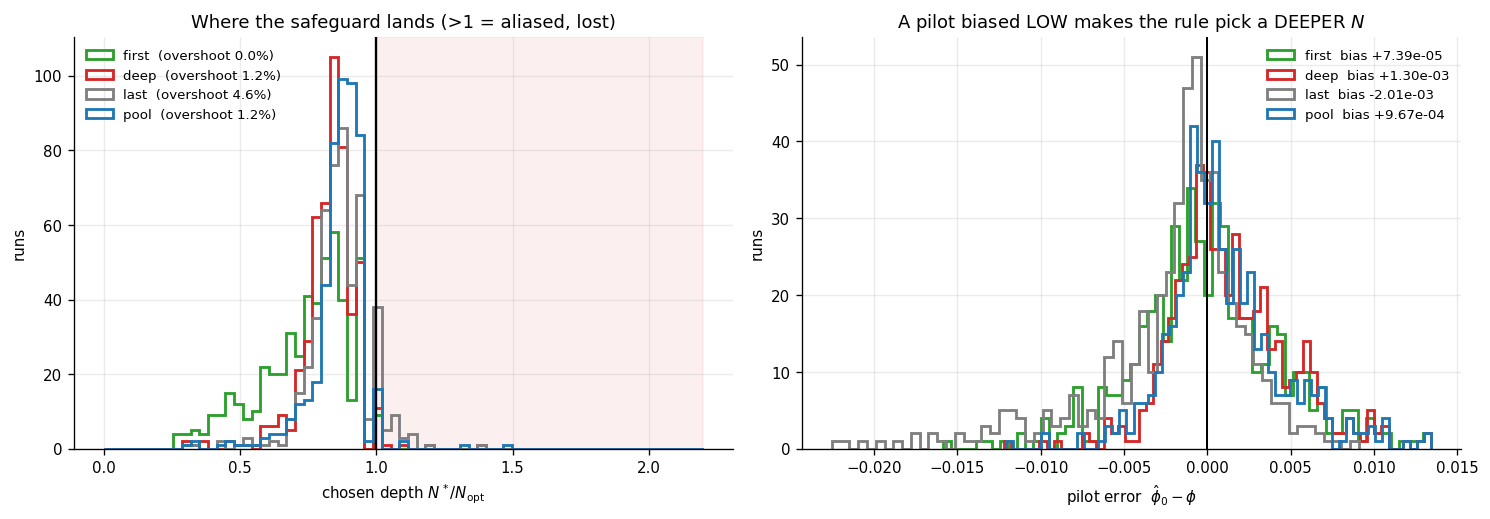

In [7]:
runs = sample_runs(500)
print(f"{len(runs)} usable runs")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
ratios = {v: np.array([r["picks"][v]["N"] / r["N_opt"] for r in runs]) for v in VARIANTS}

for v in VARIANTS:
    axes[0].hist(np.clip(ratios[v], 0, 2.2), bins=np.linspace(0, 2.2, 70), histtype="step",
                 lw=1.7, color=COL[v], label=f"{v}  (overshoot {100*(ratios[v]>1).mean():.1f}%)")
axes[0].axvline(1.0, color="k", lw=1.4)
axes[0].axvspan(1.0, 2.2, color="#d62728", alpha=0.07)
axes[0].set(xlabel=r"chosen depth $N^*/N_{\rm opt}$", ylabel="runs",
            title="Where the safeguard lands (>1 = aliased, lost)")
axes[0].legend(fontsize=8)

# pilot error against the true phase -- the mechanism
for v in VARIANTS:
    err = np.array([r["picks"][v]["phi_pilot"] - r["phi"] for r in runs])
    axes[1].hist(err, bins=60, histtype="step", lw=1.7, color=COL[v],
                 label=f"{v}  bias {err.mean():+.2e}")
axes[1].axvline(0, color="k", lw=1.2)
axes[1].set(xlabel=r"pilot error  $\hat\phi_0-\phi$", ylabel="runs",
            title="A pilot biased LOW makes the rule pick a DEEPER $N$")
axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()


## 5. The optimisation landscape each pilot sees

Same trial, four different objective curves. The rule maximises
$P(\text{no overshoot})\times P(\text{converge})$; a more precise pilot (smaller $\sigma$) makes the
first factor fall off more sharply, so it is *confident* — which is only an advantage if it is also
*right*.


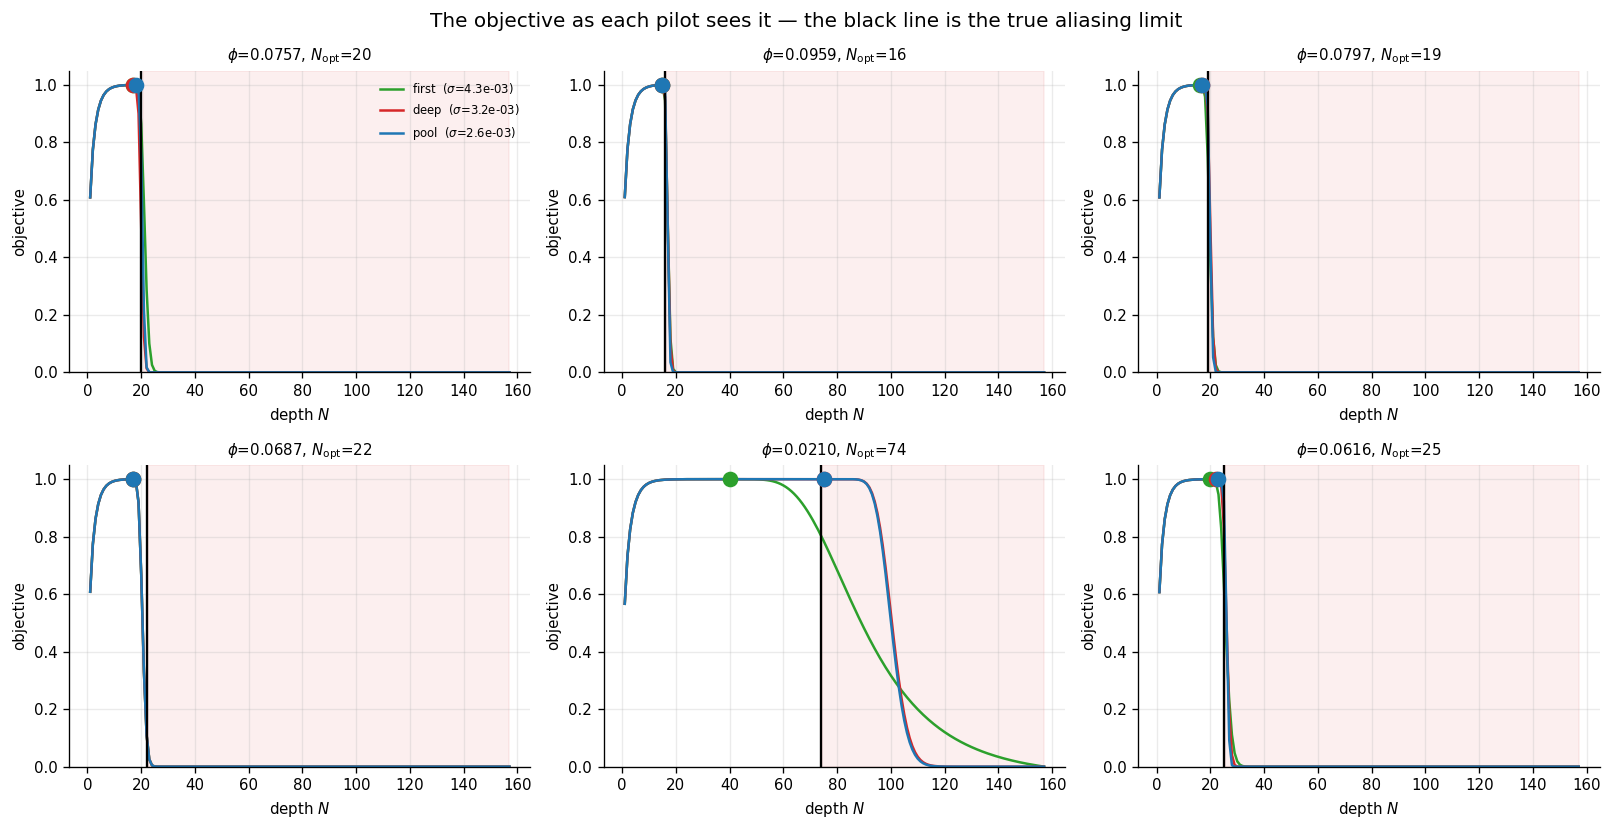

In [8]:
def plot_landscape(r, ax=None, show=("first", "deep", "pool")):
    ax = ax or plt.gca()
    N = np.arange(1, r["N_max"] + 1)
    for v in show:
        d = r["picks"].get(v)
        if d is None:
            continue
        y = score(N, d["phi_pilot"], d["sigma"], r["rem"], r["eps"], (r["phi_min"], r["phi_max"]))
        ax.plot(N, y, color=COL[v], lw=1.5, label=rf"{v}  ($\sigma$={d['sigma']:.1e})")
        ax.scatter([d["N"]], [y[d["N"] - 1]], color=COL[v], s=70, zorder=5)
    ax.axvline(r["N_opt"], color="k", lw=1.4)
    ax.axvspan(r["N_opt"] + 0.5, r["N_max"], color="#d62728", alpha=0.07)
    ax.set(xlabel="depth $N$", ylabel="objective", ylim=(0, None))
    return ax


fig, axes = plt.subplots(2, 3, figsize=(13.5, 7.0))
for ax, r in zip(axes.ravel(), sample_runs(6, seed0=40)):
    plot_landscape(r, ax)
    ax.set_title(f"$\\phi$={r['phi']:.4f}, $N_{{\\rm opt}}$={r['N_opt']}", fontsize=9)
axes[0, 0].legend(fontsize=7)
fig.suptitle("The objective as each pilot sees it — the black line is the true aliasing limit", fontsize=12)
fig.tight_layout(); plt.show()


## 6. Statistical evaluation

Convergence rate is what actually matters. Each variant is run on the **same** trials (paired seeds),
so the comparison is far tighter than two independent samples would be: we can report the paired
difference and its standard error directly.

`conf` is the overshoot test's confidence — it controls how aggressively probes are flagged, and it is
the parameter the `deep`/`pool` pilots depend on most, so it is swept rather than fixed.


In [9]:
def evaluate(n=4000, budget=BUDGET, m_exp=M_EXP, conf=CONF, seed0=10_000, **s):
    """Paired evaluation: every variant sees the identical trial (same phi, same exploration)."""
    s = {**SET, **s}
    conv = {v: [] for v in VARIANTS}
    over = {v: [] for v in VARIANTS}
    N_max = max(int(np.pi // (2 * s["phi_min"])), 1)
    for k in range(n):
        rng = np.random.default_rng(seed0 + k)
        phi = float(rng.uniform(s["phi_min"], s["phi_max"]))
        out = explore(rng, phi, s["phi_max"], s["phi_min"], m_exp, budget, conf)
        if out is None:
            continue
        probes, used = out
        rem = budget - used
        if rem <= 0:
            continue
        n_opt = max(1, int(np.pi // (2 * phi)))
        for v in VARIANTS:
            pil = pilot_from(probes, m_exp, v)
            if pil is None or not np.isfinite(pil[0]):
                conv[v].append(0.0); over[v].append(0.0); continue
            N = risk_optimal_depth(pil[0], pil[1], rem, s["eps"], N_max,
                                   (s["phi_min"], s["phi_max"]))
            # fresh exploitation shots, drawn from a stream that does not depend on the variant
            r2 = np.random.default_rng((seed0 + k) * 7919 + 13)
            ph = simulate(r2, phi, int(rem / N), N)
            conv[v].append(float(abs(ph - phi) < s["eps"]))
            over[v].append(float(N > n_opt))
    return {v: (np.array(conv[v]), np.array(over[v])) for v in VARIANTS}


res = evaluate(4000)
base = res["deep"][0]
print(f"{'variant':8s} {'converged':>10s} {'overshoot':>10s}   {'vs deep (paired)':>18s}")
for v in VARIANTS:
    c, o = res[v]
    d = c - base
    se = d.std(ddof=1) / np.sqrt(len(d))
    tag = "  (baseline)" if v == "deep" else f"  {100*d.mean():+.2f} +/- {100*1.96*se:.2f} pp"
    print(f"{v:8s} {100*c.mean():9.2f}% {100*o.mean():9.2f}% {tag:>20s}")


variant   converged  overshoot     vs deep (paired)
first        99.98%      0.00%    +0.75 +/- 0.27 pp
deep         99.22%      0.88%           (baseline)
last         95.43%      5.30%    -3.80 +/- 0.60 pp
pool         98.95%      1.30%    -0.27 +/- 0.19 pp


### Sweeping the overshoot confidence

If `deep` loses, the natural defence is that `conf` was not tuned for it. Below, every variant across
a range of `conf`, so each one is seen at its own best setting.


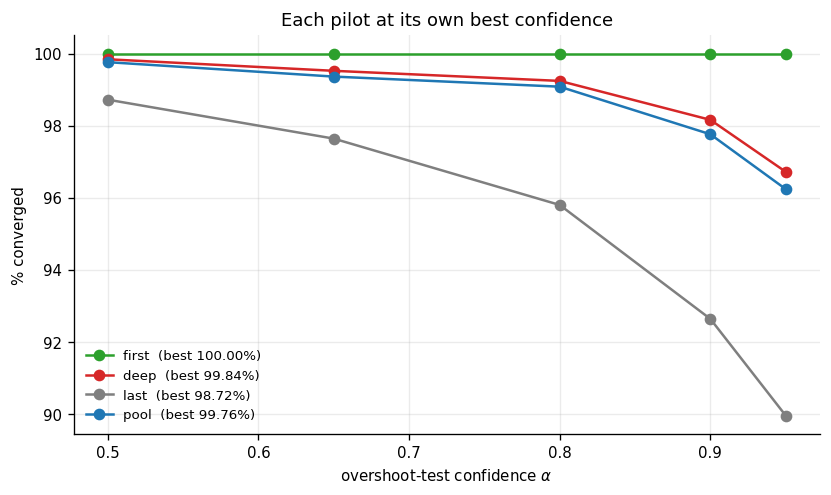

first    best 100.00%  at conf=0.5
deep     best  99.84%  at conf=0.5
last     best  98.72%  at conf=0.5
pool     best  99.76%  at conf=0.5


In [10]:
CONFS = [0.5, 0.65, 0.8, 0.9, 0.95]
rows = {v: [] for v in VARIANTS}
for c in CONFS:
    r = evaluate(2500, conf=c)
    for v in VARIANTS:
        rows[v].append(100 * r[v][0].mean())

fig, ax = plt.subplots(figsize=(7.0, 4.2))
for v in VARIANTS:
    ax.plot(CONFS, rows[v], marker="o", color=COL[v], label=f"{v}  (best {max(rows[v]):.2f}%)")
ax.set(xlabel=r"overshoot-test confidence $\alpha$", ylabel="% converged",
       title="Each pilot at its own best confidence")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

for v in VARIANTS:
    print(f"{v:8s} best {max(rows[v]):6.2f}%  at conf={CONFS[int(np.argmax(rows[v]))]}")


### Does the answer depend on the budget?

The precision-vs-aliasing balance shifts with budget: a larger budget buys a better pilot *and* rewards
a deeper circuit.


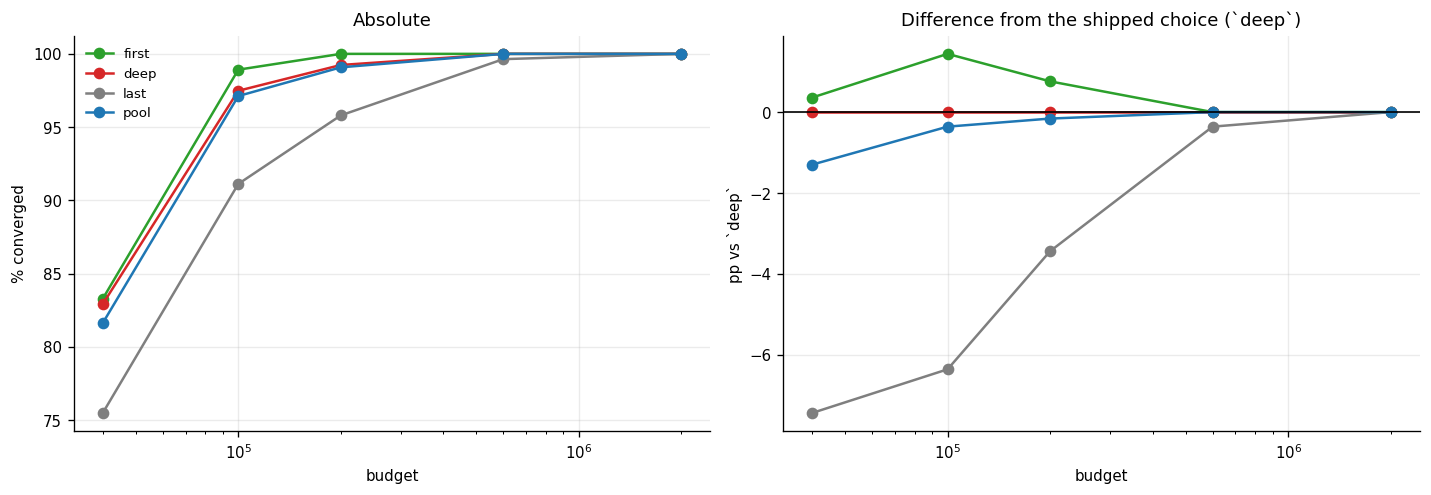

In [11]:
BUDGETS = [40_000, 100_000, 200_000, 600_000, 2_000_000]
curve = {v: [] for v in VARIANTS}
for b in BUDGETS:
    r = evaluate(2500, budget=b)
    for v in VARIANTS:
        curve[v].append(100 * r[v][0].mean())

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2))
for v in VARIANTS:
    axes[0].plot(BUDGETS, curve[v], marker="o", color=COL[v], label=v)
    axes[1].plot(BUDGETS, np.array(curve[v]) - np.array(curve["deep"]), marker="o", color=COL[v],
                 label=v)
axes[0].set(xscale="log", xlabel="budget", ylabel="% converged", title="Absolute")
axes[1].axhline(0, color="k", lw=1.0)
axes[1].set(xscale="log", xlabel="budget", ylabel="pp vs `deep`",
            title="Difference from the shipped choice (`deep`)")
axes[0].legend(fontsize=8)
fig.tight_layout(); plt.show()


## 7. Read-out — what the full study found

`analysis/binary_pilot_study.py` runs this over 3 scenarios x 6 budgets, **grid-tuning `m'` and `conf`
separately for each variant** (so no variant is handicapped by another's settings) and validating on an
independent seed at $R=40{,}000$. Over the 12 live operating points, against the shipped `deep`:

| variant | mean vs `deep` | median | worst | best | wins | mean overshoot |
|---|---:|---:|---:|---:|---:|---:|
| `first` | **+0.04 pp** | +0.06 | −0.80 | +0.66 | 50 % | 0.93 % |
| `deep` (shipped) | 0 | 0 | 0 | 0 | — | 1.10 % |
| `last` | **−1.34 pp** | −1.03 | −4.39 | +0.72 | 17 % | 4.91 % |
| `pool` | +0.24 pp | +0.10 | −0.11 | +1.17 | 75 % | 1.13 % |

The standard error of a difference at one point is 0.35 pp, so over 12 points the mean carries
about ±0.10 pp.

**`first` and `deep` are indistinguishable.** That is the answer, and the mechanism is the interesting
part — it is *not* that the extra precision fails to matter:

| variant | mean pilot bias | model $\sigma$ | bias in units of $\sigma$ |
|---|---:|---:|---:|
| `first` | $+3.3\cdot10^{-4}$ | $3.8\cdot10^{-3}$ | **0.09** |
| `deep` | $+2.4\cdot10^{-3}$ | $2.7\cdot10^{-3}$ | **0.87** |
| `pool` | $+2.0\cdot10^{-3}$ | $2.2\cdot10^{-3}$ | 0.90 |
| `last` | $-2.8\cdot10^{-4}$ | $3.1\cdot10^{-3}$ | −0.09 |

`deep` really does cut $\sigma$ by ~30 %. But the probe it selects was selected **for having read high** —
acceptance means $\hat\phi\ge\phi_1$ — so it carries a selection bias of nearly one full $\sigma$, which
the model's $\sigma$ does not know about. The precision gained and the honesty lost cancel almost
exactly. A smaller $\sigma$ that is wrong by $0.87\sigma$ is not a better pilot.

Note the sign: the bias is **upward**, so the rule believes $\phi$ is larger than it is and picks a
*shallower* depth. `deep` is therefore conservative rather than dangerous — it loses a little precision,
not a lot of trials.

**`last` is the one genuinely bad choice** (−1.34 pp, overshoot 4.91 % vs 1.10 %): it can be a probe the
test flagged as an overshoot, i.e. an aliased reading, which biases the pilot *down* and pushes $N$
deeper. If "use the most recent estimate" is read literally, this is what it means, and it is worse.

**`pool` is the only tempting option** — +0.24 pp, ahead at 75 % of points — but the margin is about two
standard errors, it needs its own derivation (inverse-variance weighting), and it inherits the same
selection bias. Not worth a re-run.

One caveat visible in the cells above: at a **fixed** `conf` the gap is larger (`first` beat `deep` by
+0.75 ± 0.27 pp, paired). Letting each variant tune its own `conf` is what closes it — `deep` recovers by
choosing a laxer test, which admits probes earlier and reduces the selection bias.


## 8. And should the depth simply be $L$?

$L$ is the deepest probe the bisection did **not** flag. It looks like a verified-safe depth, so why
run Eq. (3.8) at all? `analysis/binary_depth_study.py` measures it on the same harness (each rule
tuning its own $m'$ and `conf`, $R=40{,}000$, 12 live points, SE 0.35 pp):

| depth rule | mean vs shipped | median | worst | wins |
|---|---:|---:|---:|---:|
| $N^{*}$ from Eq. (3.8), uncapped (**shipped**) | — | — | — | — |
| $N=L$ | **−6.18 pp** | −7.59 | −11.25 | 0 % |
| $\min(N^{*},L)$ | −1.34 pp | −1.38 | −2.48 | 0 % |
| $\max(N^{*},L)$ | −3.66 pp | −3.09 | −10.27 | 8 % |

| | median depth / $N_{\rm opt}$ | $\mathbb P(\text{depth}>N_{\rm opt})$ |
|---|---:|---:|
| $L$ | 0.917 | **19.6 % (up to 40 %)** |
| $N^{*}$ | 0.827 | **1.1 % (up to 3.5 %)** |

**$L$ answers the wrong question.** The bisection exists to *locate* the aliasing boundary, so $L$
converges onto $N_{\rm opt}$ — and having converged onto it, noise puts it on the wrong side often. The
overshoot test's type-I error is moreover **absorbing**: $L$ is a running maximum, so one accepted
probe above $N_{\rm opt}$ leaves $L$ in the aliased region for good. $L$ estimates the limit the protocol
must stay below; it says nothing about the margin, and zero margin is the one answer certainly wrong.

Note also $N^{*}>L$ in **31.7 %** of trials — the rule often wants a depth the bisection never verified,
which is why capping at $L$ also costs (−1.34 pp).

Run the cell below to reproduce the comparison here at a single operating point.


In [12]:
def depth_of(r, rule):
    L = max(n for n, _p, a in r["probes"] if a)
    Ns = r["picks"]["deep"]["N"]
    return {"risk": Ns, "L": L, "min": max(min(Ns, L), 1), "max": max(Ns, L)}[rule]


def evaluate_depths(n=4000, budget=BUDGET, m_exp=M_EXP, conf=CONF, seed0=77_000, **s):
    s = {**SET, **s}
    rules = ["risk", "L", "min", "max"]
    conv = {k: [] for k in rules}
    over = {k: [] for k in rules}
    N_max = max(int(np.pi // (2 * s["phi_min"])), 1)
    for k in range(n):
        rng = np.random.default_rng(seed0 + k)
        phi = float(rng.uniform(s["phi_min"], s["phi_max"]))
        out = explore(rng, phi, s["phi_max"], s["phi_min"], m_exp, budget, conf)
        if out is None:
            continue
        probes, used = out
        rem = budget - used
        if rem <= 0:
            continue
        pil = pilot_from(probes, m_exp, "deep")
        if pil is None or not np.isfinite(pil[0]):
            continue
        Ns = risk_optimal_depth(pil[0], pil[1], rem, s["eps"], N_max, (s["phi_min"], s["phi_max"]))
        r = dict(probes=probes, picks={"deep": {"N": Ns}})
        n_opt = max(1, int(np.pi // (2 * phi)))
        for rule in rules:
            N = depth_of(r, rule)
            r2 = np.random.default_rng((seed0 + k) * 7919 + 13)
            ph = simulate(r2, phi, int(rem / N), N)
            conv[rule].append(float(abs(ph - phi) < s["eps"]))
            over[rule].append(float(N > n_opt))
    return {k: (np.array(conv[k]), np.array(over[k])) for k in rules}


res_d = evaluate_depths(4000)
base = res_d["risk"][0]
print(f"{'rule':6s} {'converged':>10s} {'overshoot':>10s} {'vs risk (paired)':>20s}")
for k in ["risk", "L", "min", "max"]:
    c, o = res_d[k]
    d = c - base
    se = d.std(ddof=1) / np.sqrt(len(d)) if d.std() > 0 else 0.0
    tag = "  (baseline)" if k == "risk" else f"  {100*d.mean():+.2f} +/- {100*1.96*se:.2f} pp"
    print(f"{k:6s} {100*c.mean():9.2f}% {100*o.mean():9.2f}% {tag:>22s}")


rule    converged  overshoot     vs risk (paired)
risk       99.25%      0.97%             (baseline)
L          73.42%     34.58%     -25.82 +/- 1.36 pp
min        99.25%      0.97%      +0.00 +/- 0.00 pp
max        73.42%     34.58%     -25.82 +/- 1.36 pp
